In [1]:
# Optional: check GPU and mount Google Drive (for saving results)
!nvidia-smi  # ➤ shows GPU details in Colab (optional)

# If you want to save outputs to Drive, uncomment the next lines:
# from google.colab import drive
# drive.mount('/content/drive')


Tue Jun 23 08:46:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
!pip install --upgrade pip
!pip install diffusers==0.22.1 transformers accelerate safetensors huggingface-hub==0.18.0 --quiet
!pip install "torch>=2.2.0" torchvision --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.18.0 which is incompatible.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.35.2 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.18.0 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.18.0 which is incompatible.
gradio-client 1.14.0 requires huggingface-hub<2.0,>=0.19.3, but you have huggingface-hub 0.18.0 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.18.0 which is incompatible.


In [1]:
!pip install -q diffusers accelerate transformers safetensors

In [3]:
import torch
import transformers
import diffusers

print("All good!")

All good!


In [4]:
#Hugging Face
#Secure HF login: set HUGGINGFACE_TOKEN in env
import os, getpass
from huggingface_hub import login

if "HUGGINGFACE_TOKEN" not in os.environ or not os.environ["HUGGINGFACE_TOKEN"]:
    os.environ["HUGGINGFACE_TOKEN"] = getpass.getpass("🔐 Enter your HuggingFace token (hf_...): ")

login(token=os.environ["HUGGINGFACE_TOKEN"])
print(" Hugging Face login successful.")  # ➤


🔐 Enter your HuggingFace token (hf_...): ··········
Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /root/.cache/huggingface/token
Login successful
 Hugging Face login successful.


In [8]:
!pip uninstall -y huggingface_hub transformers diffusers accelerate

Found existing installation: huggingface-hub 0.18.0
Uninstalling huggingface-hub-0.18.0:
  Successfully uninstalled huggingface-hub-0.18.0
Found existing installation: transformers 4.35.2
Uninstalling transformers-4.35.2:
  Successfully uninstalled transformers-4.35.2
Found existing installation: diffusers 0.22.1
Uninstalling diffusers-0.22.1:
  Successfully uninstalled diffusers-0.22.1
Found existing installation: accelerate 0.32.1
Uninstalling accelerate-0.32.1:
  Successfully uninstalled accelerate-0.32.1


In [9]:
!pip install -q \
torch \
diffusers \
transformers \
accelerate \
safetensors \
huggingface_hub

In [10]:
import torch
import transformers
import diffusers
import huggingface_hub

print(torch.__version__)
print(transformers.__version__)
print(diffusers.__version__)
print(huggingface_hub.__version__)

2.11.0+cu128
4.35.2
0.22.1
0.18.0


In [1]:
from diffusers import StableDiffusionPipeline

print("Diffusers working!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Diffusers working!


In [2]:
#Imports & config
from pathlib import Path
import torch
import numpy as np
from diffusers import StableDiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

class CFG:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    seed = 42
    generator = torch.Generator(device).manual_seed(seed)
    image_gen_steps = 35
    image_gen_model_id = "runwayml/stable-diffusion-v1-5"
    image_gen_size = (400, 400)
    image_gen_guidance_scale = 9.0
    prompt_gen_model_id = "gpt2"
    prompt_dataset_size = 6
    prompt_max_length = 12

print("Device ->", CFG.device)  # ➤


Device -> cuda


In [3]:
# Robust Stable Diffusion / SDXL loader
# v1.5, v2.1, and SDXL models safely
from diffusers import StableDiffusionPipeline
try:
    from diffusers import StableDiffusionXLPipeline
except ImportError:
    StableDiffusionXLPipeline = None

model_id = CFG.image_gen_model_id

def load_sd_pipeline(model_id, device):
    is_xl = any(word in model_id.lower() for word in ["xl", "sdxl", "stable-diffusion-xl"])

    try:
        #SDXL
        if is_xl:
            if StableDiffusionXLPipeline is None:
                raise ImportError("Update diffusers to use SDXL models.")

            pipe = StableDiffusionXLPipeline.from_pretrained(
                model_id,
                torch_dtype=torch.float16 if device == "cuda" else torch.float32
            )
            pipe = pipe.to(device)
            print(f" Loaded SDXL model: {model_id} on {device}")
            return pipe

        #Stable Diffusion v1.5 / v2.1
        try:
            pipe = StableDiffusionPipeline.from_pretrained(
                model_id,
                torch_dtype=torch.float16,
                revision="fp16"
            )
        except Exception:
            pipe = StableDiffusionPipeline.from_pretrained(
                model_id,
                torch_dtype=torch.float32
            )

        pipe = pipe.to(device)
        print(f"Loaded SD pipeline: {model_id} on {device}")
        return pipe

    except Exception as e:
        raise RuntimeError(f" Failed to load {model_id}. Reason: {e}")

# Load the pipeline
pipe = load_sd_pipeline(model_id, CFG.device)


Couldn't connect to the Hub: 404 Client Error. (Request ID: Root=1-6a3a51f7-4a6de10c08d0f9653a75664f;507ed95a-7ec3-4b43-a12f-96b4aa37c489)

Revision Not Found for url: https://huggingface.co/api/models/stable-diffusion-v1-5/stable-diffusion-v1-5/revision/fp16.
Invalid rev id: fp16.
Will try to load from local cache.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loaded SD pipeline: runwayml/stable-diffusion-v1-5 on cuda


In [4]:
#show & save
def show_image(img, title=None):
    plt.figure(figsize=(6,6))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.imshow(img)
    plt.show()

def save_image(img, out_path):
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    img.save(out_path)
    print("Saved:", out_path)  # ➤


In [5]:
#Function to generate images from prompt using pipeline
def generate_image(prompt, pipe, size=CFG.image_gen_size, steps=CFG.image_gen_steps,
                   guidance_scale=CFG.image_gen_guidance_scale, generator=CFG.generator):
    out = pipe(
        prompt,
        num_inference_steps=steps,
        guidance_scale=guidance_scale,
        generator=generator
    )
    image = out.images[0]
    image = image.resize(size)
    return image


Generating [1/1] → A serene forest at dawn, photorealistic, ultra-detailed


  0%|          | 0/35 [00:00<?, ?it/s]

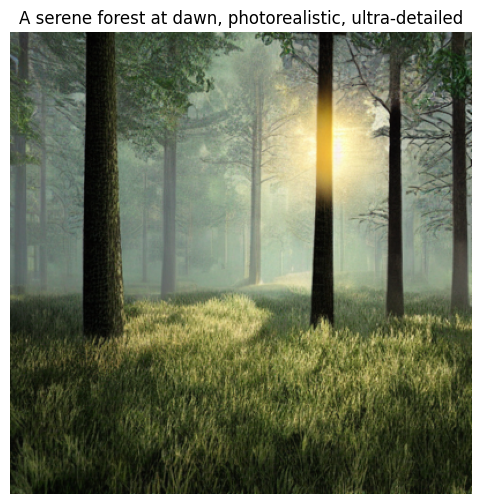

Saved: outputs/image_1.png


In [7]:
# examples
prompts = [
    "A serene forest at dawn, photorealistic, ultra-detailed",

]
for i, p in enumerate(prompts):
    print(f"Generating [{i+1}/{len(prompts)}] → {p}")  # ➤
    img = generate_image(p, pipe)
    show_image(img, title=p)
    save_image(img, f"outputs/image_{i+1}.png")


  0%|          | 0/35 [00:00<?, ?it/s]

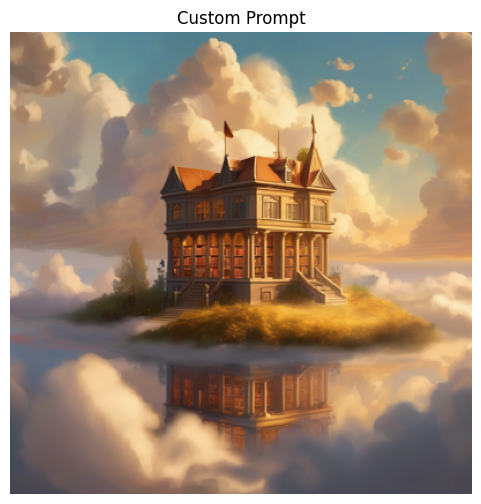

Saved: outputs/custom_prompt.png


In [ ]:
custom_prompt = "A magical library floating in the clouds, warm golden light, painterly"
img_custom = generate_image(custom_prompt, pipe, steps=CFG.image_gen_steps)
show_image(img_custom, title="Custom Prompt")
save_image(img_custom, "outputs/custom_prompt.png")


In [8]:
# Save simple metadata for reproducibility
import json
meta = {
    "model_id": CFG.image_gen_model_id,
    "steps": CFG.image_gen_steps,
    "guidance_scale": CFG.image_gen_guidance_scale,
    "seed": CFG.seed,
}
Path("outputs").mkdir(parents=True, exist_ok=True)
with open("outputs/metadata.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Metadata saved to outputs/metadata.json")  # ➤


Metadata saved to outputs/metadata.json


In [10]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 104.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [streamlit]


In [16]:
%%writefile app.py
import io
import os
import re
import time
import datetime
import streamlit as st

# ── Hardcoded HF token ────────────────────────────────────────────────────────
HF_TOKEN = "YOUR_HF_TOKEN"

# ══════════════════════════════════════════════════════════════════════════════
# SAFETY: Blocked keyword sets
# ══════════════════════════════════════════════════════════════════════════════
BLOCKED_TERMS = [
    # nudity / sexual
    "nude", "naked", "nsfw", "explicit", "pornographic", "sexual", "xxx",
    "hentai", "erotic", "lingerie", "topless", "bottomless", "genitals",
    # minors + sexual context
    "child nude", "baby nude", "minor nude", "loli", "shota",
    # gore / violence
    "gore", "decapitated", "dismembered", "mutilated", "blood splatter",
    "torture", "snuff", "beheaded",
    # hate symbols
    "swastika", "nazi", "kkk", "hate symbol",
    # deepfakes
    "deepfake",
]

# Combos blocked together but individually ok
SENSITIVE_COMBOS = [
    ({"child", "baby", "infant", "toddler", "minor"}, {"sexy", "seductive", "revealing", "nude", "naked"}),
    ({"blood"}, {"realistic", "photo", "photograph"}),
]

def _check_safety(text: str):
    lower = text.lower()
    for term in BLOCKED_TERMS:
        if term in lower:
            return f"Your prompt contains restricted content: **{term}**."
    for group_a, group_b in SENSITIVE_COMBOS:
        if any(w in lower for w in group_a) and any(w in lower for w in group_b):
            matched_a = next(w for w in group_a if w in lower)
            matched_b = next(w for w in group_b if w in lower)
            return f"Combining '{matched_a}' and '{matched_b}' is not permitted."
    return None


# ══════════════════════════════════════════════════════════════════════════════
# PROMPT ENHANCEMENT — universal, subject-aware engine
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Universal base negative (quality only — applies to everything) ─────────
BASE_NEGATIVE_UNIVERSAL = (
    "blurry, worst quality, low quality, low resolution, pixelated, "
    "jpeg artifacts, grainy, noisy, oversaturated, washed out, "
    "watermark, signature, text overlay, logo, border, frame, "
    "duplicate, clone, out of frame, cropped badly"
)

# ── 2. Subject-category negatives (only added when category is detected) ──────
CATEGORY_NEGATIVES = {
    "human": (
        "deformed eyes, crossed eyes, asymmetrical eyes, extra eyes, "
        "deformed face, distorted face, disfigured face, poorly drawn face, melting face, "
        "deformed hands, extra fingers, missing fingers, fused fingers, mutated hands, "
        "wrong number of fingers, extra arms, extra legs, missing arms, missing legs, "
        "deformed limbs, floating limbs, disconnected limbs, bad anatomy, bad proportions, "
        "twisted torso, broken spine, impossible pose, contorted body, mutated body"
    ),
     "baby": (
        # Face & head
        "adult face, teenage face, old face, mature face, sharp jawline, "
        "defined cheekbones, adult nose, narrow nose, thin lips, adult teeth, "
        "wrinkled adult skin, aged skin, stubble, beard, makeup, "
        "asymmetrical face, deformed face, distorted face, uncanny valley face, "
        "creepy face, doll face, mannequin face, plastic face, "
        # Eyes
        "adult eyes, narrow eyes, sunken eyes, hollow eyes, dark undereye circles, "
        "heavy eyelids, mascara, eyeliner, eyeshadow, "
        # Body proportions
        "adult body proportions, long limbs, long legs, long arms, thin limbs, "
        "muscular body, defined muscles, adult torso, narrow waist, broad shoulders, "
        "standing upright unassisted, walking, running, "
        # Hands & feet
        "adult hands, large hands, bony hands, long fingers, long nails, "
        "adult feet, large feet, "
        # Anatomy errors
        "extra limbs, missing limbs, fused fingers, extra fingers, "
        "deformed hands, malformed feet, bad anatomy, "
        # Hair
        "full head of adult hair, long flowing hair, styled hair, "
        # Clothing / context
        "adult clothing, formal suit, high heels, jewellery on adult, "
        # General quality
        "blurry face, out of focus face, flat face, featureless face, "
        "low resolution face, pixelated skin, plastic skin, wax figure"
    ),
    "animal": (
        "deformed animal, extra legs, missing legs, fused limbs, wrong number of legs, "
        "extra heads, distorted snout, malformed paws, bad animal anatomy, "
        "human hands on animal, humanoid face on animal"
    ),
    "landscape": (
        "ugly sky, overexposed sky, flat lighting, no depth, muddy colors, "
        "inconsistent lighting, floating objects, distorted horizon"
    ),
    "architecture": (
        "distorted perspective, bent walls, impossible geometry, "
        "leaning building, melting structure, inconsistent scale, "
        "floating elements, bad perspective"
    ),
    "food": (
        "unappetizing, rotten looking, discolored food, flat lighting, "
        "plastic looking, artificial colors, melted into itself"
    ),
    "vehicle": (
        "distorted wheels, wrong number of wheels, bent frame, "
        "impossible shape, melting metal, bad perspective on vehicle"
    ),
    "space_sci": (
        "flat stars, no depth in space, inconsistent lighting, "
        "wrong planet colors, no atmosphere glow"
    ),
    "abstract_art": (
        "accidental faces, unintended figures, muddy color mixing, "
        "too literal, photorealistic when abstract requested"
    ),
}

# ── 3. Style/medium quality suffixes ──────────────────────────────────────────
# Each maps a detected style to the quality terms most meaningful for that medium
STYLE_QUALITY = {
    # Photographic
    r"\b(photo|photograph|photorealistic|realistic|dslr|raw photo)\b":
        "photorealistic, DSLR quality, natural lighting, sharp focus, 8k, "
        "professional photography, color grading",
    # Cinematic
    r"\b(cinematic|film|movie|scene|dramatic)\b":
        "cinematic lighting, anamorphic lens, film grain, color graded, "
        "shallow depth of field, wide angle, epic composition",
    # Illustration / digital art
    r"\b(illustration|digital art|concept art|artwork|artstation)\b":
        "highly detailed digital illustration, concept art, trending on ArtStation, "
        "professional digital painting, vibrant colors, intricate details",
    # Watercolour
    r"\b(watercolou?r|watercolor)\b":
        "loose watercolor brushstrokes, wet-on-wet technique, soft edges, "
        "transparent washes, white paper showing through, delicate pigment blooms",
    # Oil painting
    r"\b(oil painting|oil on canvas|painted)\b":
        "impasto texture, visible brushstrokes, rich oil pigment, canvas texture, "
        "old masters technique, chiaroscuro lighting",
    # Pencil / sketch
    r"\b(sketch|pencil|charcoal|drawing|line art)\b":
        "detailed pencil sketch, cross-hatching, expressive line work, "
        "textured paper, tonal shading",
    # Anime / manga
    r"\b(anime|manga|cel.?shad|cartoon)\b":
        "anime style, clean cell shading, vibrant flat colors, crisp outlines, "
        "expressive eyes, dynamic composition",
    # 3D render
    r"\b(3d render|cgi|blender|octane|unreal engine|ray.?trac)\b":
        "photorealistic 3D render, subsurface scattering, global illumination, "
        "ray-traced reflections, 4K render, Octane render quality",
    # Pixel art
    r"\b(pixel art|8.?bit|16.?bit|retro game)\b":
        "crisp pixel art, limited color palette, clean pixel edges, "
        "retro game sprite style, no anti-aliasing",
    # Macro / close-up
    r"\b(macro|close.?up|extreme close)\b":
        "macro photography, extreme detail, bokeh background, "
        "studio lighting, sharp subject, shallow DOF",
    # Portrait
    r"\b(portrait|headshot|face|close portrait)\b":
        "professional portrait photography, studio lighting, sharp focus on face, "
        "bokeh background, skin detail, catchlight in eyes",
    # Landscape / nature
    r"\b(landscape|scenery|nature|wilderness|vista|panorama)\b":
        "epic landscape photography, golden hour lighting, wide angle lens, "
        "rich colors, atmospheric depth, National Geographic quality",
    # Architecture / interior — exclude gym, lab, studio which have their own boosters
    r"\b(architecture|building|interior design|room|house|city|skyscraper|facade|bridge|tower|castle|temple|street|urban)\b":
        "architectural photography, perfect perspective lines, even lighting, "
        "sharp detail, professional real estate quality",
    # Food / product
    r"\b(food|dish|meal|cuisine|product|still life)\b":
        "food photography, soft box lighting, shallow DOF, appetizing colors, "
        "professional plating, commercial quality",
    # Fantasy / sci-fi
    r"\b(fantasy|sci.?fi|futuristic|magical|mystical|dragon|wizard)\b":
        "epic fantasy art, intricate world-building details, dramatic lighting, "
        "rich color palette, highly detailed environment, cinematic scale",
    # Space / cosmic
    r"\b(space|galaxy|nebula|cosmos|planet|star|universe)\b":
        "NASA quality space imagery, deep field photography, accurate stellar colors, "
        "nebula gas clouds, cinematic cosmic scale",
    # Abstract
    r"\b(abstract|surreal|dreamlike|psychedelic|geometric)\b":
        "visually striking abstract composition, bold color contrasts, "
        "harmonious shapes, intentional design, gallery quality",
    # Minimalist
    r"\b(minimal|minimalist|simple|clean)\b":
        "minimalist composition, negative space, clean lines, "
        "restrained color palette, deliberate composition",
}

# ── 4. Subject-specific scene boosters (activity/prop grounding) ──────────────
SCENE_BOOSTERS = {
    # Human activities
    r"\bskating?\b":      "ice skating rink background, skates on feet, motion blur on blades",
    r"\bsurfing\b":       "surfboard underfoot, ocean wave, spray of water, wetsuit",
    r"\bskiing\b":        "ski slopes, skis attached to feet, poles in hands, snow",
    r"\bsnowboard\b":     "snowboard underfoot, snow slope, winter jacket, goggles",
    r"\bgym\b":           "gym interior, weight racks, mirrors, gym equipment visible",
    r"\bswimming\b":      "pool or ocean water, swim cap or goggles, wet skin",
    r"\bdancing\b":       "dance floor or stage, motion blur on feet, dramatic lighting",
    r"\bballet\b":        "ballet studio, pointe shoes, tutu, barre visible",
    r"\byoga\b":          "yoga mat, studio or outdoor setting, stretching pose",
    r"\bcooking\b":       "kitchen background, apron, cooking utensils in hand, steam",
    r"\bpainting\b":      "artist studio, canvas on easel, paintbrush in hand, palette",
    r"\breading\b":       "open book in hands, cozy comfortable setting, soft lighting",
    r"\bgardening\b":     "garden background, soil, gloves, trowel or watering can",
    r"\bclimbing\b":      "rock wall or cliff face, climbing harness, chalk on hands",
    r"\bhorseback\b":     "horse beneath rider, saddle, riding helmet, open field",
    r"\bfishing\b":       "lake or river, fishing rod in hand, tackle box, water reflection",
    r"\barchery\b":       "archery range or forest, bow drawn, arrow nocked, focused gaze",
    r"\bboxing\b":        "boxing ring, gloves on hands, footwork stance, gym background",
    r"\bfootball\b":      "football field, turf, sports kit, ball mid-action",
    r"\bcricket\b":       "cricket pitch, bat in hand, whites uniform, stumps visible",
    # Clothing in unusual contexts
    r"\bgown\b":          "full-length formal gown with realistic fabric drape and folds",
    r"\bsaree?\b":        "traditional saree with correct draping, intricate border embroidery",
    r"\bsuit\b":          "well-tailored suit jacket and matching trousers, sharp lapels",
    r"\bkimono\b":        "traditional Japanese kimono, obi belt, correct fabric drape",
    r"\bkurta\b":         "traditional kurta with collar and embroidery, churidar or pajama",
    # Anthropomorphic animals
    r"\b(dog|puppy).{0,25}(skat|surf|cook|danc|play|driv|read|paint|danc)":
                          "anthropomorphic dog, correct canine anatomy, bipedal stance, expressive face",
    r"\b(cat|kitten).{0,25}(skat|surf|cook|danc|play|driv|read|paint)":
                          "anthropomorphic cat, correct feline anatomy, bipedal stance, expressive face",
    r"\b(bear|lion|tiger|fox|rabbit).{0,25}(skat|surf|cook|danc|play|driv|read)":
                          "anthropomorphic animal character, correct animal anatomy adapted for action, expressive",
    # Environments
    r"\b(underwater|ocean floor|deep sea)\b":
                          "caustic light rays, bubbles, blue-green water tones, underwater haze, coral or sand",
    r"\b(space|outer space|zero gravity)\b":
                          "stars in background, planet curvature, vacuum blackness, astronaut suit if human present",
    r"\b(forest|jungle|woods)\b":
                          "dappled light through canopy, rich green foliage, forest floor detail, depth of trees",
    r"\b(desert|sand dunes?|sahara)\b":
                          "rolling sand dunes, harsh sunlight, heat shimmer, minimal vegetation",
    r"\b(mountain|cliff|peak|summit)\b":
                          "dramatic elevation, rocky terrain, distant peaks in background, atmospheric haze",
    r"\b(city|cityscape|skyline|urban)\b":
                          "detailed building facades, street level perspective or aerial view, ambient city lighting",
    r"\b(cafe|coffee shop|restaurant)\b":
                          "warm ambient lighting, tables and chairs, menu board or decor visible",
    r"\b(library|bookshelf|study)\b":
                          "rows of books, warm reading light, wooden shelves, cozy atmosphere",
    r"\b(laboratory|lab|science)\b":
                          "scientific equipment, glassware, controlled lighting, sterile environment",
    # Food specifics
    r"\b(pizza)\b":       "melted cheese pull, charred crust, fresh toppings, rustic wooden board",
    r"\b(burger|hamburger)\b":
                          "stacked layers visible, sesame bun, fresh vegetables, sauce drip",
    r"\b(sushi)\b":       "precise knife cuts, nori wrap, rice texture, minimalist plate presentation",
    r"\b(cake|pastry|dessert)\b":
                          "rich texture, perfect cross-section slice, soft ambient lighting, garnish",
    r"\b(pasta|noodles?)\b":
                          "sauce coating visible, steam rising, al dente texture, rustic bowl",
    # Vehicles
    r"\b(car|automobile|vehicle)\b":
                          "correct wheel count, realistic reflections, proper perspective, detailed bodywork",
    r"\b(motorcycle|bike)\b":
                          "correct two-wheel anatomy, engine detail, realistic chrome reflections",
    r"\b(airplane|aircraft|jet)\b":
                          "correct wing anatomy, engine placement, perspective matching flight angle",
    r"\b(ship|boat|vessel)\b":
                          "waterline visible, hull detail, correct nautical proportions, water reflection",
    # Time of day — lighting grounding
    r"\b(sunset|golden hour|dusk)\b":
                          "warm golden orange light, long shadows, sun near horizon, glowing sky",
    r"\b(sunrise|dawn)\b":
                          "soft pink and orange hues, morning mist, gentle warm light",
    r"\b(night|midnight|nocturnal)\b":
                          "moonlight or artificial light sources, deep shadows, stars or city lights",
    r"\b(storm|lightning|thunder)\b":
                          "dramatic clouds, lightning bolt if requested, rain streaks, moody atmosphere",
    r"\b(fog|mist|misty)\b":
                          "soft diffused light, reduced contrast, atmospheric perspective, muted palette",
}

# ── 5. Age-to-description mapping (human subjects only) ───────────────────────
MONTH_DESCRIPTIONS = {
    (0, 1):  "newborn, days old, very tiny, wrinkled skin, swaddled, eyes barely open",
    (1, 3):  "1-3 month old infant, very small round face, tiny fists, lying on back, onesie",
    (3, 6):  "3-6 month old baby, starting to hold head up, chubby cheeks, no teeth, rounded body",
    (6, 9):  "6-9 month old baby, sitting with support, first tooth appearing, babbling expression",
    (9, 12): "9-12 month old baby, pulling to stand, few teeth, chubby toddler face",
}
YEAR_DESCRIPTIONS = {
    (1, 3):   "toddler, very short, chubby round face, diaper or toddler clothes, stumbling walk",
    (3, 6):   "preschool child, short stature, round face, playful expression, bright children's clothes",
    (6, 10):  "school-age child, gap-toothed smile, kid proportions, backpack or casual clothes",
    (10, 13): "preteen, growing but child-like proportions, casual modern clothes",
    (13, 18): "teenager, teen proportions, modern streetwear or casual clothes",
    (18, 30): "young adult, lean fit proportions, modern clothing",
    (30, 50): "middle-aged adult, mature features",
    (50, 70): "older adult, some grey hair, mature distinguished face",
    (70, 120):"elderly person, white or grey hair, deeply wrinkled face, deliberate posture",
}

def _detect_subject_category(lower: str) -> list[str]:
    """Return list of active subject categories for targeted negative injection."""
    cats = []
    if re.search(r"\b(person|man|woman|boy|girl|child|baby|infant|toddler|human|people|face|portrait)\b", lower):
        cats.append("human")
    if re.search(r"\b(baby|infant|newborn|neonate|toddler|[0-9]+\s*month[s]?\s*old)\b", lower):
        cats.append("baby")
    if re.search(r"\b(dog|cat|horse|bird|fish|lion|tiger|bear|wolf|fox|rabbit|elephant|deer|animal|creature|pet)\b", lower):
        cats.append("animal")
    if re.search(r"\b(landscape|scenery|mountain|valley|forest|desert|ocean|lake|river|field|sky|clouds?)\b", lower):
        cats.append("landscape")
    if re.search(r"\b(building|architecture|house|interior|room|city|street|bridge|tower|castle|temple)\b", lower):
        cats.append("architecture")
    if re.search(r"\b(food|meal|dish|cuisine|pizza|burger|sushi|cake|pasta|fruit|vegetable|drink|coffee)\b", lower):
        cats.append("food")
    if re.search(r"\b(car|truck|motorcycle|bike|airplane|ship|boat|train|vehicle|aircraft)\b", lower):
        cats.append("vehicle")
    if re.search(r"\b(space|galaxy|nebula|planet|star|cosmos|universe|astronaut)\b", lower):
        cats.append("space_sci")
    if re.search(r"\b(abstract|geometric|surreal|psychedelic|pattern|fractal)\b", lower):
        cats.append("abstract_art")
    return cats

def _enrich_age(prompt: str):
    lower = prompt.lower()
    # Only apply if this is a human subject
    if not re.search(r"\b(person|man|woman|boy|girl|child|baby|infant|toddler|human|newborn|neonate)\b", lower):
        return prompt, ""
    extra_pos, extra_neg = [], []
    m = re.search(r"(\d+)\s*-?\s*month", lower)
    if m:
        months = int(m.group(1))
        for (lo, hi), desc in MONTH_DESCRIPTIONS.items():
            if lo <= months < hi:
                extra_pos.append(desc)
                extra_neg.append("adult proportions, standing, walking, teeth, long limbs, toddler")
                break
        else:
            extra_pos.append(f"approximately {months} month old infant, infant proportions")
            extra_neg.append("adult proportions, toddler, child")
    m2 = re.search(r"(\d+)\s*(?:year[s]?\s*old|yr[s]?\s*old|y\.?o\.?)", lower)
    if m2:
        years = int(m2.group(1))
        for (lo, hi), desc in YEAR_DESCRIPTIONS.items():
            if lo <= years < hi:
                extra_pos.append(desc)
                break
    if not m and not m2:
        if re.search(r"\b(newborn|neonate)\b", lower):
            extra_pos.append("newborn baby, days old, very small, swaddled, round face")
            extra_neg.append("standing, walking, adult, long limbs")
        elif re.search(r"\b(infant|baby)\b", lower):
            extra_pos.append("infant baby, round chubby face, small body, baby clothes")
            extra_neg.append("adult proportions, long limbs, standing unassisted")
        elif re.search(r"\btoddler\b", lower):
            extra_pos.append("toddler aged 1-3 years, chubby face, short legs, diaper or toddler clothes")
            extra_neg.append("adult proportions")
    enriched = prompt
    if extra_pos:
        enriched = prompt.rstrip(". ,") + ", " + ", ".join(extra_pos)
    return enriched, ", ".join(extra_neg)

def _enrich_style(prompt: str) -> str:
    """Append style-appropriate quality tokens if no style already detected."""
    lower = prompt.lower()
    additions = []
    for pattern, quality in STYLE_QUALITY.items():
        if re.search(pattern, lower):
            additions.append(quality)
    # Deduplicate while preserving order
    seen, unique = set(), []
    for item in additions:
        if item not in seen:
            seen.add(item)
            unique.append(item)
    if unique:
        return prompt.rstrip(". ,") + ", " + ", ".join(unique)
    # No style detected → apply generic high-quality fallback
    return prompt.rstrip(". ,") + ", highly detailed, sharp focus, 8k resolution, professional quality, vibrant colors"

def _enrich_scene(prompt: str) -> str:
    """Append scene/prop grounding hints for any matched activity or environment."""
    additions = []
    lower = prompt.lower()
    for pattern, booster in SCENE_BOOSTERS.items():
        if re.search(pattern, lower):
            additions.append(booster)
    if additions:
        return prompt.rstrip(". ,") + ", " + ", ".join(additions)
    return prompt

def _build_final_prompt(prompt: str, user_negative: str):
    lower = prompt.lower()

    # Step 1: age enrichment (only for humans)
    enriched, age_neg = _enrich_age(prompt)

    # Step 2: scene / prop grounding (universal)
    enriched = _enrich_scene(enriched)

    # Step 3: style-aware quality suffix (universal)
    enriched = _enrich_style(enriched)

    # Step 4: build targeted negative
    categories = _detect_subject_category(lower)
    neg_parts = [BASE_NEGATIVE_UNIVERSAL]
    for cat in categories:
        if cat in CATEGORY_NEGATIVES:
            neg_parts.append(CATEGORY_NEGATIVES[cat])
    if age_neg:
        neg_parts.append(age_neg)
    if user_negative.strip():
        neg_parts.append(user_negative.strip())
    final_neg = ", ".join(neg_parts)

    return enriched, final_neg


# ══════════════════════════════════════════════════════════════════════════════
# UI SETUP
# ══════════════════════════════════════════════════════════════════════════════
BG_PAGE=      "#0e1a2b"
BG_INPUT=     "#132440"
BG_CARD=      "#16476A"
BG_SIDEBAR=   "#0b1520"
BORDER=       "#1e3a56"
BORDER_FOCUS= "#FDB5CE"
TEXT_PRI=     "#f0f4f8"
TEXT_SEC=     "#c9a8bc"
TEXT_MUTED=   "#5a7a8a"
ACCENT=       "#FDB5CE"
METRIC_BG=    "#132440"
SLIDER_TRACK= "#1e3a56"
PILL_BG=      "rgba(253,181,206,.15)"
PILL_BOR=     "rgba(253,181,206,.35)"
OK_BG=        "rgba(59,151,151,.12)"
OK_BOR=       "rgba(59,151,151,.30)"
OK_TXT=       "#7dd3d3"
ERR_BG=       "rgba(253,181,206,.10)"
ERR_BOR=      "rgba(253,181,206,.30)"
ERR_TXT=      "#FDB5CE"
WARN_BG=      "rgba(251,191,36,.09)"
WARN_BOR=     "rgba(251,191,36,.26)"
WARN_TXT=     "#fbbf24"

st.set_page_config(
    page_title="Imagine",
    page_icon="✿",
    layout="centered",
    initial_sidebar_state="expanded",
)

if "prompt_value" not in st.session_state:
    st.session_state.prompt_value = ""

st.markdown(f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600&family=Playfair+Display:ital,wght@0,700;1,400&display=swap');
*, *::before, *::after {{ box-sizing: border-box; }}
html, body, [class*="css"], .stApp {{
    font-family: 'Inter', sans-serif !important;
    background: {BG_PAGE} !important;
    color: {TEXT_PRI} !important;
}}
.stApp {{ background: {BG_PAGE} !important; }}
section[data-testid="stSidebar"] {{
    background: {BG_SIDEBAR} !important;
    border-right: 1px solid rgba(253,181,206,.2) !important;
}}
section[data-testid="stSidebar"] label,
section[data-testid="stSidebar"] p,
section[data-testid="stSidebar"] span,
section[data-testid="stSidebar"] div {{ color: {TEXT_PRI} !important; }}
div[data-testid="stSlider"] [data-baseweb="slider"] [role="slider"] {{
    background: {ACCENT} !important; border-color: {ACCENT} !important;
    box-shadow: 0 0 0 4px {PILL_BG} !important;
}}
[data-baseweb="slider"] > div > div:first-child {{ background: {SLIDER_TRACK} !important; }}
[data-baseweb="slider"] > div > div:first-child > div {{
    background: linear-gradient(90deg, #FDB5CE, #fce4ee) !important;
}}
div[data-testid="stSelectbox"] > div > div {{
    background: {BG_INPUT} !important; border: 1px solid {BORDER} !important;
    border-radius: 10px !important; color: {TEXT_PRI} !important;
}}
div[data-testid="stSelectbox"] > div > div:hover {{ border-color: {ACCENT} !important; }}
div[data-testid="stNumberInput"] input {{
    background: {BG_INPUT} !important; border: 1px solid {BORDER} !important;
    border-radius: 10px !important; color: {TEXT_PRI} !important;
}}
div[data-testid="stTextArea"] textarea {{
    background: {BG_INPUT} !important; border: 1px solid {BORDER} !important;
    border-radius: 14px !important; color: {TEXT_PRI} !important;
    font-family: 'Inter', sans-serif !important; font-size: .93rem !important;
    line-height: 1.65 !important; padding: .9rem 1.1rem !important;
    resize: vertical !important; transition: border-color .2s, box-shadow .2s;
}}
div[data-testid="stTextArea"] textarea::placeholder {{ color: {TEXT_MUTED} !important; }}
div[data-testid="stTextArea"] textarea:focus {{
    border-color: {BORDER_FOCUS} !important;
    box-shadow: 0 0 0 3px {PILL_BG} !important; outline: none !important;
}}
div[data-testid="stTextArea"] label {{ display: none !important; }}
div[data-testid="stTextInput"] input {{
    background: {BG_INPUT} !important; border: 1px solid {BORDER} !important;
    border-radius: 10px !important; color: {TEXT_PRI} !important;
    font-family: 'Inter', sans-serif !important; font-size: .88rem !important;
}}
div[data-testid="stTextInput"] input::placeholder {{ color: {TEXT_MUTED} !important; }}
div[data-testid="stTextInput"] input:focus {{
    border-color: {BORDER_FOCUS} !important;
    box-shadow: 0 0 0 3px {PILL_BG} !important; outline: none !important;
}}
div[data-testid="stButton"] > button {{
    background: linear-gradient(135deg, #FDB5CE, #e8829e) !important;
    color: #0e1a2b !important; border: none !important;
    border-radius: 14px !important; font-weight: 700 !important;
    font-size: 1rem !important; padding: .85rem 0 !important; width: 100% !important;
    box-shadow: 0 4px 28px rgba(253,181,206,.35) !important;
    transition: opacity .2s, transform .1s, box-shadow .2s !important;
}}
div[data-testid="stButton"] > button:hover {{
    opacity: .9 !important; transform: translateY(-1px) !important;
    box-shadow: 0 8px 36px rgba(253,181,206,.50) !important;
}}
div[data-testid="stDownloadButton"] > button {{
    background: {BG_CARD} !important; color: {ACCENT} !important;
    border: 1px solid rgba(253,181,206,.35) !important; border-radius: 10px !important;
    font-size: .9rem !important; font-weight: 500 !important; width: 100% !important;
    padding: .7rem 0 !important;
}}
div[data-testid="stDownloadButton"] > button:hover {{
    border-color: {ACCENT} !important; background: {PILL_BG} !important;
}}
#MainMenu, footer, header {{ visibility: hidden !important; }}
div[data-testid="stToolbar"] {{ display: none !important; }}
.ui-hero {{ text-align: center; padding: 2.2rem 0 1.6rem; }}
.ui-hero-icon {{ font-size: 2.6rem; display: block; margin-bottom: .6rem;
    filter: drop-shadow(0 0 20px rgba(253,181,206,.7)); }}
.ui-hero h1 {{ font-family: 'Playfair Display', serif; font-size: 2.6rem;
    font-weight: 700; letter-spacing: -.02em; margin: 0 0 .4rem;
    background: linear-gradient(135deg, #FDB5CE 0%, #fce4ee 50%, #3B9797 100%);
    -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; }}
.ui-hero p {{ color: {TEXT_SEC}; font-size: .92rem; margin: 0; font-weight: 300; }}
.status-pill {{ display: inline-flex; align-items: center; gap: .4rem;
    padding: .3rem 1.1rem; border-radius: 100px; font-size: .74rem;
    font-weight: 500; background: {PILL_BG}; border: 1px solid {PILL_BOR};
    color: {ACCENT}; margin-top: 1rem; }}
.status-dot {{ width: 7px; height: 7px; border-radius: 50%; background: #FDB5CE;
    animation: pulse 2.2s infinite; }}
@keyframes pulse {{
    0%, 100% {{ opacity:1; box-shadow:0 0 0 0 rgba(253,181,206,.5); }}
    50% {{ opacity:.6; box-shadow:0 0 0 5px rgba(253,181,206,0); }}
}}
.section-label {{ font-size: .67rem; font-weight: 600; letter-spacing: .14em;
    text-transform: uppercase; color: #FDB5CE; margin: 1.5rem 0 .55rem; opacity: .7; }}
.char-counter {{ font-size: .73rem; text-align: right; margin-top: -.15rem; margin-bottom: .5rem; }}
.ui-divider {{ border: none; border-top: 1px solid rgba(253,181,206,.15); margin: 1.4rem 0; }}
.msg-ok   {{ background:{OK_BG};  border:1px solid {OK_BOR};  color:{OK_TXT};
    border-radius:10px; padding:.7rem 1rem; font-size:.87rem; margin:.6rem 0; }}
.msg-err  {{ background:{ERR_BG}; border:1px solid {ERR_BOR}; color:{ERR_TXT};
    border-radius:10px; padding:.7rem 1rem; font-size:.87rem; margin:.6rem 0; }}
.msg-warn {{ background:{WARN_BG};border:1px solid {WARN_BOR};color:{WARN_TXT};
    border-radius:10px; padding:.7rem 1rem; font-size:.87rem; margin:.6rem 0; }}
.msg-block {{ background:rgba(220,38,38,.12); border:1px solid rgba(220,38,38,.35);
    color:#f87171; border-radius:10px; padding:.7rem 1rem; font-size:.87rem; margin:.6rem 0; }}
.img-frame {{ border:1px solid rgba(253,181,206,.25); border-radius:18px;
    overflow:hidden; margin:1rem 0; box-shadow:0 8px 40px rgba(253,181,206,.10); }}
.img-frame:hover {{ border-color:rgba(253,181,206,.5); box-shadow:0 12px 52px rgba(253,181,206,.20); }}
.metrics-grid {{ display:grid; grid-template-columns:repeat(3,1fr); gap:.65rem; margin-top:.8rem; }}
.metric-card {{ background:{METRIC_BG}; border:1px solid {BORDER}; border-radius:10px; padding:.8rem 1rem; }}
.metric-label {{ font-size:.64rem; color:{TEXT_MUTED}; text-transform:uppercase; letter-spacing:.1em; margin-bottom:.25rem; }}
.metric-value {{ font-size:1.05rem; font-weight:600; color:{TEXT_PRI}; }}
.debug-box {{ background:#0a111d; border:1px solid #1e3a56; border-radius:10px;
    padding:.75rem 1rem; font-size:.75rem; color:{TEXT_MUTED};
    font-family:monospace; margin-top:.5rem; white-space:pre-wrap; word-break:break-word; }}
.sidebar-info {{ color:{TEXT_MUTED}; font-size:.76rem; line-height:1.65; margin-top:.5rem; }}
.sidebar-info span {{ color:#FDB5CE; }}
</style>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL LOADER
# ══════════════════════════════════════════════════════════════════════════════
def _get_device_label():
    try:
        import torch
        if torch.cuda.is_available():
            return torch.cuda.get_device_name(0)
    except Exception:
        pass
    return "CPU"

@st.cache_resource(show_spinner="Loading model — one moment…")
def load_pipeline():
    import torch
    from diffusers import StableDiffusionPipeline
    from huggingface_hub import login
    login(token=HF_TOKEN)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype  = torch.float16 if device == "cuda" else torch.float32
    pipe   = StableDiffusionPipeline.from_pretrained(
        "stable-diffusion-v1-5/stable-diffusion-v1-5",
        torch_dtype=dtype,
        safety_checker=None,   # our keyword gate handles safety
    ).to(device)
    if device == "cuda":
        pipe.enable_attention_slicing()
    return pipe, device


# ══════════════════════════════════════════════════════════════════════════════
# HERO
# ══════════════════════════════════════════════════════════════════════════════
device_label = _get_device_label()

st.markdown(f"""
<div class="ui-hero">
  <span class="ui-hero-icon">✿</span>
  <h1>Imagine</h1>
  <p>Turn a description into a unique image in seconds.</p>
  <div>
    <span class="status-pill">
      <span class="status-dot"></span>
      Ready &nbsp;·&nbsp; {device_label}
    </span>
  </div>
</div>
""", unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# SIDEBAR
# ══════════════════════════════════════════════════════════════════════════════
with st.sidebar:
    st.markdown("""
    <p style="font-family:'Playfair Display',serif;font-size:1.15rem;font-weight:700;
              color:#FDB5CE;margin:0 0 1.2rem;letter-spacing:-.01em">
      ✿ Settings
    </p>
    """, unsafe_allow_html=True)

    steps    = st.slider("Quality  (inference steps)", 20, 60, 50, 5,
                         help="More steps = sharper result, longer wait.")
    guidance = st.slider("Creativity  (guidance scale)", 5.0, 15.0, 7.5, 0.5,
                         help="7–8.5 is best for faces/bodies. Higher = more literal.")

    size_option = st.selectbox("Output size",
                               ["512 × 512", "768 × 512", "512 × 768"], index=0)
    SIZE_MAP = {"512 × 512": (512, 512), "768 × 512": (768, 512), "512 × 768": (512, 768)}
    out_w, out_h = SIZE_MAP[size_option]

    seed = st.number_input("Seed", 0, 2**31 - 1, 42, 1,
                           help="Same seed + same prompt = same image.")

    show_debug = st.checkbox("Show enhanced prompt", value=False,
                             help="Shows the full prompt sent to the model after enrichment.")

    st.markdown('<hr style="border:none;border-top:1px solid rgba(253,181,206,.15);margin:1.2rem 0">',
                unsafe_allow_html=True)
    st.markdown(f"""
    <p class="sidebar-info">
      Model: <span>stable-diffusion-v1-5</span><br>
      Backend: <span>🤗 Diffusers</span><br>
      Device: <span>{device_label}</span>
    </p>
    """, unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# PROMPT INPUT
# ══════════════════════════════════════════════════════════════════════════════
st.markdown('<div class="section-label">Describe your image</div>', unsafe_allow_html=True)

EXAMPLES = [
    "A magical library floating in clouds, golden light, painterly",
    "Cyberpunk city in the rain, neon reflections, 4K",
    "Portrait of a fox in autumn forest, soft watercolour",
    "A 3 month old baby sleeping on a white blanket",
    "A golden retriever dog ice skating in a rink",
    "A man wearing a tuxedo at the gym lifting weights",
]

prompt = st.text_area(
    "p",
    value=st.session_state.prompt_value,
    placeholder=(
        "Describe the image you want to create…\n\n"
        "  • A magical library floating in clouds, golden light\n"
        "  • A 3-month-old baby sleeping on a blanket\n"
        "  • A dog ice skating in a rink"
    ),
    height=130,
    max_chars=300,
    label_visibility="collapsed",
    key="prompt_textarea",
)

char_count = len(prompt)
char_color = WARN_TXT if char_count > 270 else TEXT_MUTED
st.markdown(
    f'<div class="char-counter" style="color:{char_color}">{char_count} / 300</div>',
    unsafe_allow_html=True,
)

negative_prompt = st.text_input(
    "Negative prompt (optional)",
    placeholder="Add anything extra to avoid — anatomy fixes are already applied automatically.",
)

# ── Example chips ─────────────────────────────────────────────────────────────
st.markdown('<div class="section-label">✿ Try an example</div>', unsafe_allow_html=True)
cols = st.columns(len(EXAMPLES))
for i, (col, ex) in enumerate(zip(cols, EXAMPLES)):
    with col:
        short = ex[:18] + "…" if len(ex) > 18 else ex
        if st.button(short, key=f"ex_{i}", help=ex):
            st.session_state.prompt_value = ex
            st.rerun()

st.markdown('<hr class="ui-divider">', unsafe_allow_html=True)


# ══════════════════════════════════════════════════════════════════════════════
# GENERATE
# ══════════════════════════════════════════════════════════════════════════════
generate = st.button("✿  Generate Image", use_container_width=True)

if generate:
    p = prompt.strip()

    if not p:
        st.markdown('<div class="msg-warn">⚠ Please enter a description before generating.</div>',
                    unsafe_allow_html=True)
        st.stop()
    if len(p) < 5:
        st.markdown('<div class="msg-warn">⚠ Description is too short — add more detail.</div>',
                    unsafe_allow_html=True)
        st.stop()

    # ── Safety gate ───────────────────────────────────────────────────────────
    block_reason = _check_safety(p + " " + negative_prompt)
    if block_reason:
        st.markdown(
            f'<div class="msg-block">🚫 This prompt cannot be used. {block_reason}<br>'
            f'<small>Imagine is designed for safe, creative use only.</small></div>',
            unsafe_allow_html=True,
        )
        st.stop()

    # ── Build enriched prompts ────────────────────────────────────────────────
    final_pos, final_neg = _build_final_prompt(p, negative_prompt)

    if show_debug:
        st.markdown(
            f'<div class="debug-box">'
            f'<b style="color:#FDB5CE">✦ Positive:</b>\n{final_pos}\n\n'
            f'<b style="color:#FDB5CE">✦ Negative:</b>\n{final_neg}'
            f'</div>',
            unsafe_allow_html=True,
        )

    # ── Load model ────────────────────────────────────────────────────────────
    try:
        pipe, device = load_pipeline()
    except Exception as e:
        st.markdown(f'<div class="msg-err">✕ Failed to load model: {e}</div>',
                    unsafe_allow_html=True)
        st.stop()

    # ── Inference ─────────────────────────────────────────────────────────────
    try:
        import torch
        generator = torch.Generator(device).manual_seed(int(seed))

        with st.spinner("Creating your image…"):
            t0     = time.perf_counter()
            result = pipe(
                final_pos,
                negative_prompt=final_neg,
                num_inference_steps=steps,
                guidance_scale=guidance,
                generator=generator,
                width=out_w,
                height=out_h,
            )
            elapsed = time.perf_counter() - t0

        img = result.images[0]

        st.markdown('<div class="msg-ok">✿ Image created successfully!</div>',
                    unsafe_allow_html=True)
        st.markdown('<div class="img-frame">', unsafe_allow_html=True)
        st.image(img, use_container_width=True)
        st.markdown('</div>', unsafe_allow_html=True)

        buf = io.BytesIO()
        img.save(buf, format="PNG")
        buf.seek(0)
        ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        st.download_button(
            "⬇  Download Image",
            data=buf.getvalue(),
            file_name=f"imagine_{ts}.png",
            mime="image/png",
            use_container_width=True,
        )

        try:
            import psutil
            mem_str = f"{psutil.Process(os.getpid()).memory_info().rss/1024/1024:.0f} MB"
        except Exception:
            mem_str = "—"

        t_str = f"{elapsed:.1f}s" if elapsed < 60 else f"{int(elapsed//60)}m {elapsed%60:.1f}s"

        st.markdown(f"""
        <div style="margin-top:1.2rem">
          <div class="section-label">Generation details</div>
          <div class="metrics-grid">
            <div class="metric-card"><div class="metric-label">Time</div><div class="metric-value">{t_str}</div></div>
            <div class="metric-card"><div class="metric-label">Resolution</div><div class="metric-value">{out_w}×{out_h}</div></div>
            <div class="metric-card"><div class="metric-label">Steps</div><div class="metric-value">{steps}</div></div>
            <div class="metric-card"><div class="metric-label">Creativity</div><div class="metric-value">{guidance:.1f}</div></div>
            <div class="metric-card"><div class="metric-label">Device</div><div class="metric-value">{device_label}</div></div>
            <div class="metric-card"><div class="metric-label">Memory</div><div class="metric-value">{mem_str}</div></div>
          </div>
        </div>
        """, unsafe_allow_html=True)

    except Exception as exc:
        st.markdown(f'<div class="msg-err">✕ Something went wrong: {exc}</div>',
                    unsafe_allow_html=True)

Overwriting app.py


In [12]:
!pip install -q pyngrok

from pyngrok import ngrok

ngrok.set_auth_token("NGROKTOKEN")

In [15]:
import os
from pyngrok import ngrok

os.system("streamlit run app.py --server.port 8501 &")

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://dice-repulsive-endpoint.ngrok-free.dev" -> "http://localhost:8501"


In [18]:
!git config --global user.name "aashiipatel"
!git config --global user.email "aashipatel58959@gmail.com"

In [19]:
!git clone https://github.com/aashiipatel/Image-Generation-using-Stable-Diffusion

Cloning into 'Image-Generation-using-Stable-Diffusion'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [20]:
%cd Image-Generation-using-Stable-Diffusion

!git add .
!git commit -m "Added project files"
!git push

/content/Image-Generation-using-Stable-Diffusion
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [26]:
!pwd
!ls -lah
!git status

/content/Image-Generation-using-Stable-Diffusion
total 16K
drwxr-xr-x 3 root root 4.0K Jun 23 10:08 .
drwxr-xr-x 1 root root 4.0K Jun 23 10:08 ..
drwxr-xr-x 8 root root 4.0K Jun 23 10:11 .git
-rw-r--r-- 1 root root   41 Jun 23 10:08 README.md
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [28]:
!find /content -name "*.py"

/content/app.py
